# Phase 5 — Graph Feature Lift for the Boosting Ensemble

This notebook runs the LightGBM + XGBoost comparison on the same holdout rows:

- baseline features only
- baseline features + graph centrality and embeddings

Run all cells from top to bottom, then save the notebook before pushing it to GitHub.

In [1]:
from pathlib import Path
import json
import subprocess
import sys
import pandas as pd
from IPython.display import Image, display

# Find the repository root, regardless of which folder Jupyter starts in.
ROOT = Path.cwd().resolve()
while ROOT != ROOT.parent and not (ROOT / 'scripts').exists():
    ROOT = ROOT.parent
if not (ROOT / 'scripts' / 'phase5_graph_ensemble.py').exists():
    raise FileNotFoundError('Open this notebook inside the cloned delihivery project.')
OUTPUT = ROOT / 'artifacts' / 'phase5_graph_ensemble'
print(f'Repository: {ROOT}')
print(f'Python: {sys.executable}')

Repository: D:\iit g\projects\delihivery
Python: C:\Users\HP\AppData\Local\Programs\Python\Python313\python.exe


## Install dependencies

Run this once in a terminal, or uncomment the next cell if you want the notebook to install them using the current Python kernel:

```powershell
python -m pip install -r requirements-analysis.txt
```

In [2]:
# Optional: uncomment to install/update dependencies from this notebook.
# subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-r', str(ROOT / 'requirements-analysis.txt')])

## Run phase 5

The script loads the existing phase-3 and phase-4 checkpoints, trains both ensembles, and writes the comparison outputs.

In [3]:
run = subprocess.run(
    [sys.executable, str(ROOT / 'scripts' / 'phase5_graph_ensemble.py')],
    cwd=ROOT,
    text=True,
    capture_output=True,
    check=False,
)
print(run.stdout)
if run.returncode != 0:
    print(run.stderr)
    raise RuntimeError(f'Phase 5 failed with exit code {run.returncode}')

                                        model   mae_min  rmse_min       r2  within_15_pct  bias_min  blend_weight_lightgbm  mae_lift_vs_baseline_min  within_15_lift_pct_points
        Boosting ensemble — baseline features 29.487038 78.048924 0.979871       0.802769 -9.101335                   0.45                  0.000000                   0.000000
Boosting ensemble — baseline + graph features 28.002812 74.104994 0.981854       0.813576 -7.765180                   0.55                  1.484226                   1.080716

Graph feature share of tree gain: 3.2%
Saved phase-5 outputs to: D:\iit g\projects\delihivery\artifacts\phase5_graph_ensemble



## Results: baseline vs graph-enhanced ensemble

In [4]:
metrics = pd.read_csv(OUTPUT / 'metrics.csv')
metrics[['model', 'mae_min', 'rmse_min', 'r2', 'within_15_pct', 'mae_lift_vs_baseline_min', 'within_15_lift_pct_points']]

,model,mae_min,rmse_min,r2,within_15_pct,mae_lift_vs_baseline_min,within_15_lift_pct_points
0,Boosting ensemble — baseline features,29.487038,78.048924,0.979871,0.802769,0.000000,0.000000
1,Boosting ensemble — baseline + graph features,28.002812,74.104994,0.981854,0.813576,1.484226,1.080716


In [5]:
summary = json.loads((OUTPUT / 'summary.json').read_text(encoding='utf-8'))
print(f"MAE improvement from graph features: {summary['mae_lift_min']:.2f} minutes")
print(f"Within-15% improvement: {summary['within_15_lift_percentage_points']:.2f} percentage points")
print(f"Graph feature share of tree gain: {summary['graph_gain_share']:.1%}")

MAE improvement from graph features: 1.48 minutes
Within-15% improvement: 1.08 percentage points
Graph feature share of tree gain: 3.2%


## Graph feature visual evidence

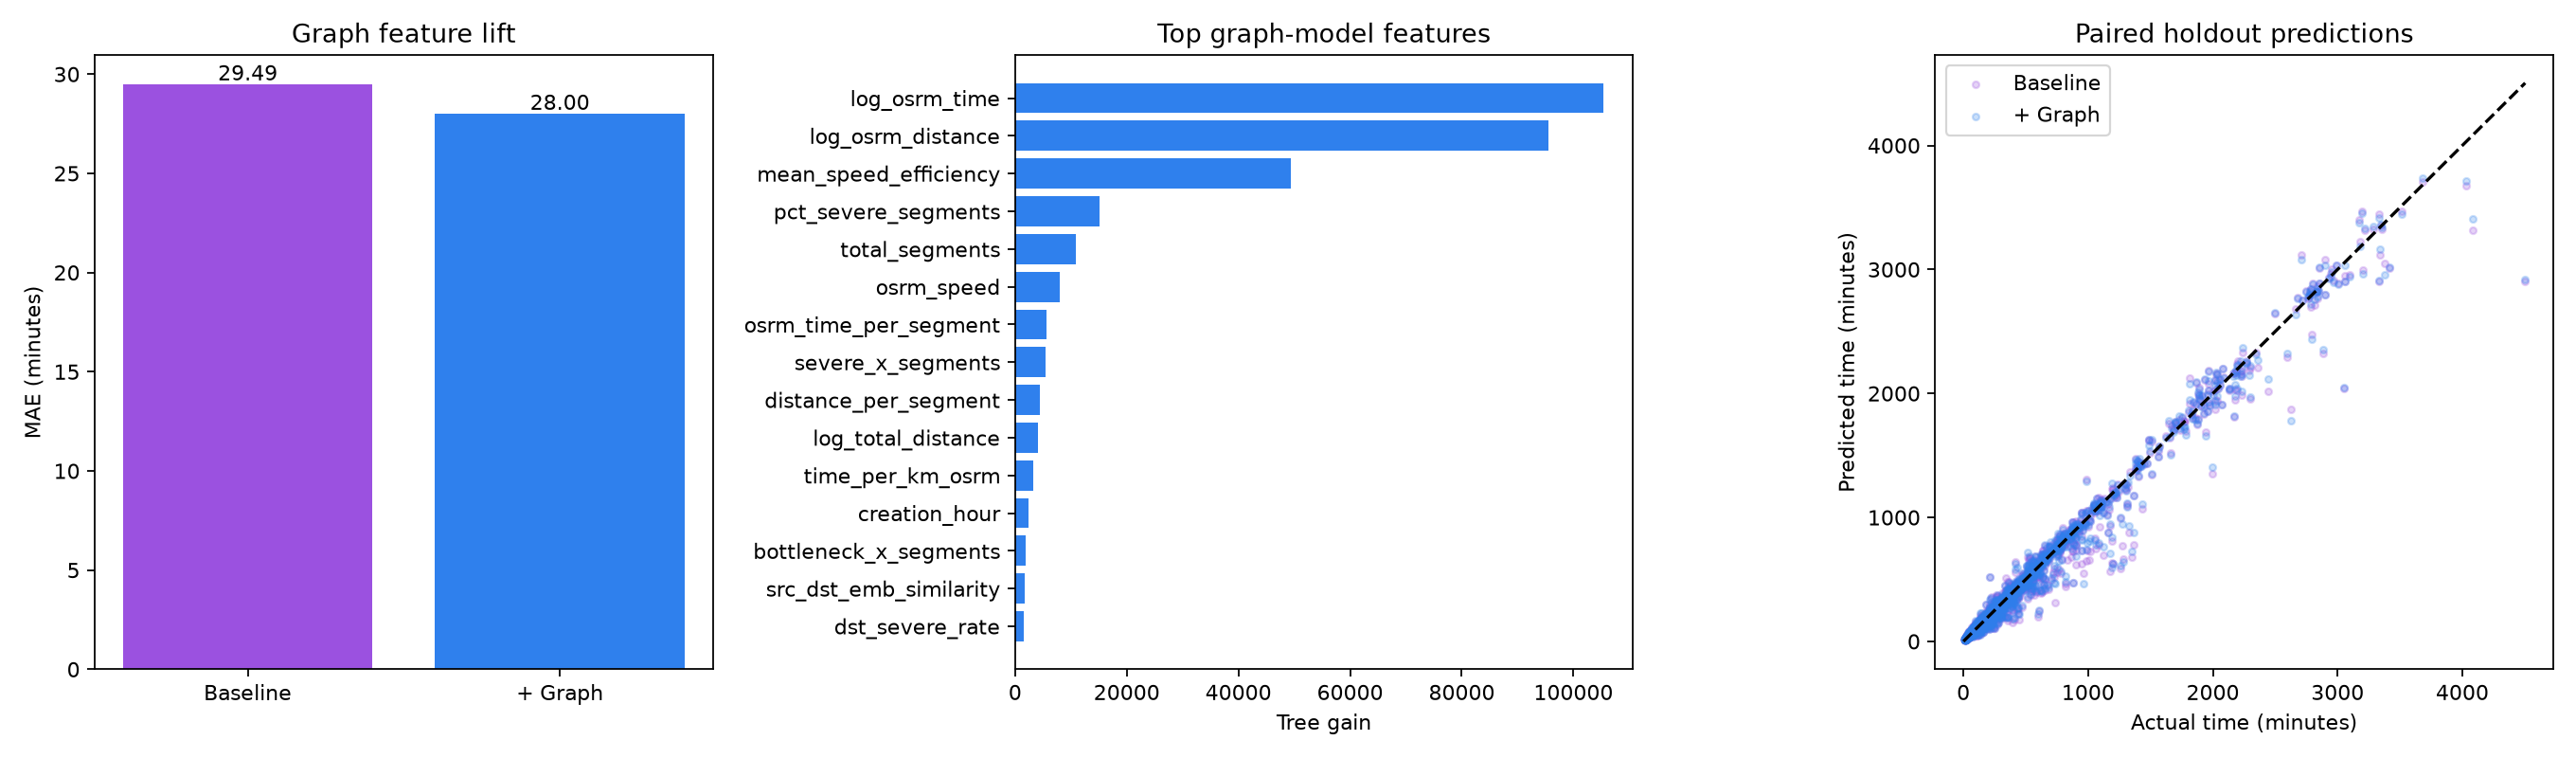

In [6]:
display(Image(filename=str(OUTPUT / 'graph_feature_lift.png')))

In [7]:
importance = pd.read_csv(OUTPUT / 'graph_model_feature_importance.csv')
importance.head(20)

,feature,lightgbm_gain,xgboost_gain,ensemble_gain
0,log_osrm_time,191644.731239,0.095695,105404.645244
1,log_osrm_distance,173661.179493,0.659608,95513.945545
2,mean_speed_efficiency,89712.600345,0.010927,49341.935107
3,pct_severe_segments,27378.386129,0.012023,15058.117782
4,total_segments,19644.341104,0.086902,10804.426713
5,osrm_speed,14461.452798,0.000994,7953.799486
6,osrm_time_per_segment,10170.828226,0.004104,5593.957371
7,severe_x_segments,10006.741025,0.004814,5503.709730
8,distance_per_segment,8028.993398,0.001926,4415.947235
9,log_total_distance,7506.028861,0.009752,4128.320262
